# Microgrids and Distributed Energy Resources

## Learn how to model microgrid configurations in PyPSA, incorporating solar, wind,
flow batteries, and demand response strategies into a unified simulation framework.

Explore the impact of renewable integration and demand-side flexibility on key
performance indicators such as operational cost, emissions, and renewable
utilization




Demonstration of a scenario-based optimization of microgrid performance using real-world time series data


From rural electrification projects in underserved areas to urban deploy­
ment in hospitals, campuses, and data centers, microgrids now serve as building
blocks in modern grid-modernization efforts

By Engr. Kwaku Duah
duah229@gmail.com

Using PyPSA, energy planners can evaluate both grid-connected and is­
landed operations, optimize system design under cost or CO2 constraints, and
explore sensitivity to various technical and policy inputs. With PyPSA users can
efficiently run linear optimization routines to assess the viability of proposed
microgrid configurations and identify optimal capacity expansions or dispatch
strategies.

This case study presents a structured simulation of a rural microgrid using
PyPSA, designed to evaluate the performance of decentralized energy systems
under varying configurations. The focus lies on understanding how distributed
energy resources (DERs) such as solar photovoltaic (PV), wind power, battery
storage, and demand response (DR) mechanisms contribute to the technical and
economic viability of microgrids.

In [1]:
import pandas as pd

# Load reduced dataset
data = pd.read_csv(
    "microgrid_input_timeseries_2020.csv",
    parse_dates=["utc_timestamp"],
    index_col="utc_timestamp",
)

In [2]:
# Select a 5-day window for simulation
start_date = "2020-01-01"
end_date = "2020-01-05"

filtered_data = data.loc[start_date:end_date]

In [3]:
# Extract individual series
load_profile = filtered_data["load_MW"].values
wind_generation_profile = filtered_data["wind_gen_MW"].values
solar_generation_profile = filtered_data["solar_gen_MW"].values

Conventional Energy Scenario, baseline network

In [4]:
import pypsa

In [5]:
# Initialise network and snaphots
baseline_network = pypsa.Network()
snapshots = pd.date_range(start=start_date, periods=120, freq="h")

baseline_network.set_snapshots(snapshots)

In [6]:
# Add microgrid bus
baseline_network.add("Bus", "Microgrid Central Bus")


# Add demand load
baseline_network.add(
    "Load", "Microgrid Load", bus="Microgrid Central Bus", p_set=load_profile
)

# Add diesel generator
baseline_network.add(
    "Generator",
    "Diesel Generator",
    bus="Microgrid Central Bus",
    p_nom=3000,  # 3MWH
    marginal_cost=100,
    carrier="diesel",
    efficiency=0.35,
)


# Add backup generator
baseline_network.add(
    "Generator",
    "Grid Supply",
    bus="Microgrid Central Bus",
    p_nom=10000,
    marginal_cost=150,
    carrier="grid",
)

Always copy the network before you OPTIMIZE

The solution reveals a dispatch
strategy in which the diesel generator is utilized up to its nominal limit, while the
remaining demand-particularly during peak hours-is met via grid imports.

Renewable Integration and Optimization Scenario

This scenario marks a clear shift in the microgrid design—away from fossil
dependence and toward a system that leverages Distributed Energy Resources
(DERs) for greater self-sufficiency and resilience. The model is expanded to
integrate solar photovoltaic (PV) and wind-turbine systems, both of which use
weather-based generation profiles extracted from real-world data. 

By simulating
the fluctuating behavior of these renewables over the same five-day window, we
aim to understand how increasing renewable shares affect dispatch dynamics,
system costs, and reliance on external supply.

Copy the baseline network before optimization


In [7]:
# this would be our base network
base_network = baseline_network.copy()

In [8]:
base_network.optimize(solver_name="gurobi")

/tmp/ipykernel_284926/2942273581.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  base_network.optimize(solver_name="gurobi")
Index(['Microgrid Central Bus'], dtype='str', name='name')
Index(['Diesel Generator', 'Grid Supply'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.04s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2827010


INFO:gurobipy:Set parameter LicenseID to value 2827010


...

Solved in 0 iterations and 0.04 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.04 seconds (0.00 work units)


Optimal objective  6.979395000e+07


INFO:gurobipy:Optimal objective  6.979395000e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 240 primals, 600 duals
Objective: 6.98e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


('ok', 'optimal')

In [10]:
print("\n=== Scenario 1: Baseline (Diesel + Grid) ===")
print(f"Total System Cost: {base_network.objective:.2f} $")
print(f"Diesel energy (MWh):", base_network.generators_t.p["Diesel Generator"].sum())
print("Grid energy (MWh): ", base_network.generators_t.p["Grid Supply"].sum())


=== Scenario 1: Baseline (Diesel + Grid) ===
Total System Cost: 69793950.00 $
Diesel energy (MWh): 360000.0
Grid energy (MWh):  225293.0


# Baseline network is the foundation

In [11]:
re_network = baseline_network.copy()

Renewable Integration (Solar + Wind)

In [12]:
# Add solar PV generator
re_network.add(
    "Generator",
    "Solar PV",
    bus="Microgrid Central Bus",
    p_nom=1000,
    marginal_cost=10,
    carrier="solar",
    p_max_pu=solar_generation_profile / max(solar_generation_profile),
    capital_cost=600,
)

In [13]:
# Add wind turbine generator
re_network.add(
    "Generator",
    "Wind Turbine",
    bus="Microgrid Central Bus",
    p_nom=1500,
    marginal_cost=12,
    carrier="wind",
    p_max_pu=wind_generation_profile / max(wind_generation_profile),
    capital_cost=800,
)

When reusing a PyPSA network for multiple scenarios, always call network.copy()
before executing network.optimize(). Once optimized, the network structure is
modified and cannot be safely duplicated. This step ensures reproducibility and
avoids runtime issues during scenario analysis

In [14]:
re_network.optimize(solver_name="gurobi")

/tmp/ipykernel_284926/1842439244.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  re_network.optimize(solver_name="gurobi")
Index(['Microgrid Central Bus'], dtype='str', name='name')
Index(['Diesel Generator', 'Grid Supply', 'Solar PV', 'Wind Turbine'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.02s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2827010


INFO:gurobipy:Set parameter LicenseID to value 2827010


...

Solved in 22 iterations and 0.03 seconds (0.00 work units)


INFO:gurobipy:Solved in 22 iterations and 0.03 seconds (0.00 work units)


Optimal objective  5.350916422e+07


INFO:gurobipy:Optimal objective  5.350916422e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 480 primals, 1080 duals
Objective: 5.35e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


('ok', 'optimal')

In [15]:
print("\n=== Scenario 2: Renewable Integration ===")
print(f"Total System Cost:  {re_network.objective:.2f} $")
print("Solar energy (MWh):", re_network.generators_t.p["Solar PV"].sum())
print("Wind energy (MWh): ", re_network.generators_t.p["Wind Turbine"].sum())
print("Diesel energy (MWh):", re_network.generators_t.p["Diesel Generator"].sum())
print("Grid energy (MWh):", re_network.generators_t.p["Grid Supply"].sum())


=== Scenario 2: Renewable Integration ===
Total System Cost:  53509164.22 $
Solar energy (MWh): 19941.43484626647
Wind energy (MWh):  99725.45454545454
Diesel energy (MWh): 354617.44349793694
Grid energy (MWh): 111008.66711034207


Demand Response

In [16]:
# Extract Load and Renewable Generation Profiles
initial_load = baseline_network.loads_t.p_set["Microgrid Load"]

solar_gen = re_network.generators_t.p["Solar PV"]
wind_gen = re_network.generators_t.p["Wind Turbine"]

In [17]:
# Create a combined renewable energy profile
combined_gen = solar_gen + wind_gen
threshold = combined_gen.quantile(0.75)

This index serves as a proxy for renewable supply intensity at each time
step. 
To distinguish between periods of surplus and scarcity, we apply a quantile­
based thresholding method—specifically, we calculate the 75th percentile (Q3)
of the combined profile. 

Hours with renewable availability above this threshold144 
are considered high-generation periods, while those below are treated as lower­
supply intervals.

In [18]:
# Define conservative and aggressive Demand Response DR adjustment factors
dr_adj_cons = combined_gen.apply(
    lambda x: 1.1 if x > threshold else 0.9  # demand adjustment conservative
)


dr_adj_aggr = combined_gen.apply(lambda x: 1.2 if x > threshold else 0.8)

In [19]:
# Modify the original load profile accordingly
load_cons = initial_load * dr_adj_cons.values
load_aggr = initial_load * dr_adj_aggr.values

In [20]:
conservative_network = baseline_network.copy()

In [21]:
conservative_network.add(
    "Generator",
    "Solar PV",
    bus="Microgrid Central Bus",
    p_nom=1000,
    marginal_cost=10,
    carrier="solar",
    p_max_pu=solar_generation_profile / max(solar_generation_profile),
    capital_cost=600,
)

# Add wind turbine generator
conservative_network.add(
    "Generator",
    "Wind Turbine",
    bus="Microgrid Central Bus",
    p_nom=1500,
    marginal_cost=12,
    carrier="wind",
    p_max_pu=wind_generation_profile / max(wind_generation_profile),
    capital_cost=800,
)

In [28]:
conservative_network.loads_t.p_set["Microgrid Load"] = load_cons

In [29]:
conservative_network.optimize(solver_name="gurobi")

/tmp/ipykernel_284926/490841373.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  conservative_network.optimize(solver_name="gurobi")
Index(['Microgrid Central Bus'], dtype='str', name='name')
Index(['Diesel Generator', 'Grid Supply', 'Solar PV', 'Wind Turbine'], dtype='str', name='name')
Index(['0'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.02s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2827010


INFO:gurobipy:Set parameter LicenseID to value 2827010


...

Solved in 23 iterations and 0.04 seconds (0.00 work units)


INFO:gurobipy:Solved in 23 iterations and 0.04 seconds (0.00 work units)


Optimal objective  4.932846204e+07


INFO:gurobipy:Optimal objective  4.932846204e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 480 primals, 1080 duals
Objective: 4.93e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


('ok', 'optimal')

In [24]:
aggressive_network = baseline_network.copy()

In [25]:
aggressive_network.add(
    "Generator",
    "Solar PV",
    bus="Microgrid Central Bus",
    p_nom=1000,
    marginal_cost=10,
    carrier="solar",
    p_max_pu=solar_generation_profile / max(solar_generation_profile),
    capital_cost=600,
)

aggressive_network.add(
    "Generator",
    "Wind Turbine",
    bus="Microgrid Central Bus",
    p_nom=1500,
    marginal_cost=12,
    carrier="wind",
    p_max_pu=wind_generation_profile / max(wind_generation_profile),
    capital_cost=800,
)

aggressive_network.loads_t.p_set["Microgrid Load"] = load_aggr

In [26]:
aggressive_network.optimize(solver_name="gurobi")

/tmp/ipykernel_284926/2698627225.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  aggressive_network.optimize(solver_name="gurobi")
Index(['Microgrid Central Bus'], dtype='str', name='name')
Index(['Diesel Generator', 'Grid Supply', 'Solar PV', 'Wind Turbine'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.02s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2827010


INFO:gurobipy:Set parameter LicenseID to value 2827010


...

Solved in 42 iterations and 0.03 seconds (0.00 work units)


INFO:gurobipy:Solved in 42 iterations and 0.03 seconds (0.00 work units)


Optimal objective  4.564277317e+07


INFO:gurobipy:Optimal objective  4.564277317e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 480 primals, 1080 duals
Objective: 4.56e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


('ok', 'optimal')

In [27]:
print("\n=== Scenario 3: Demand Response ===")
print("Conservative DR - System cost: {:.2f} $".format(conservative_network.objective))
print("Aggressive DR   - System cost: {:.2f} $".format(aggressive_network.objective))


=== Scenario 3: Demand Response ===
Conservative DR - System cost: 45642773.17 $
Aggressive DR   - System cost: 45642773.17 $


In [30]:
print("\n=== Scenario 3: Demand Response ===")
print("Conservative DR - System cost: {:.2f} $".format(conservative_network.objective))
print("Aggressive DR - System cost: {:.2f} $".format(aggressive_network.objective))


=== Scenario 3: Demand Response ===
Conservative DR - System cost: 49328462.04 $
Aggressive DR - System cost: 45642773.17 $


<Figure size 1200x600 with 0 Axes>

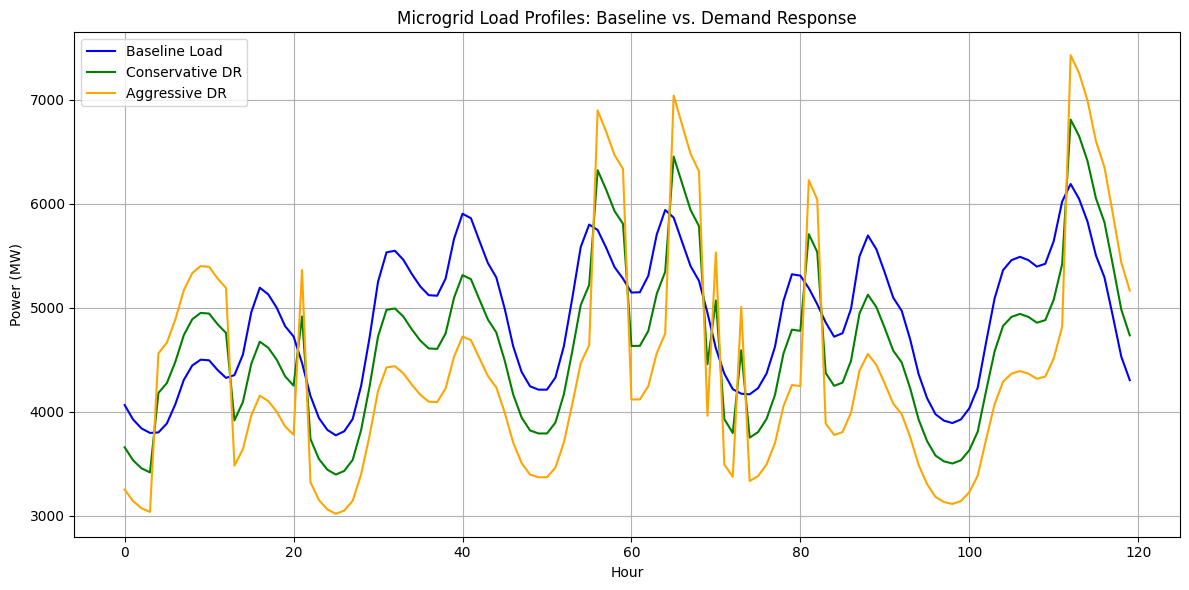

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.figure(figsize=(12, 6))
plt.plot(initial_load.values, label="Baseline Load", color="blue")
plt.plot(load_cons.values, label="Conservative DR", color="green")
plt.plot(load_aggr.values, label="Aggressive DR", color="orange")
plt.title("Microgrid Load Profiles: Baseline vs. Demand Response")
plt.xlabel("Hour")
plt.ylabel("Power (MW)")
plt.legend()
plt.grid("Baseline_Aggressive.plt")
plt.tight_layout()
plt.savefig("")
plt.show()

In [32]:
def plot_dispatch(network, title):
    gen_dispatch = network.generators_t.p

    colors = {
        "Diesel Generator": "grey",
        "Grid Supply": "red",
        "Solar PV": "orange",
        "Wind Turbine": "green",
    }

    gen_dispatch.plot(
        kind="bar",
        stacked=True,
        figsize=(14, 6),
        color=[colors.get(gen, "black") for gen in gen_dispatch.columns],
        width=0.8,
    )

    plt.title(title)
    plt.xlabel("Time (Hour)")
    plt.ylabel("Generation (MW)")
    plt.legend(title="Generation")
    plt.tight_layout()
    plt.show()

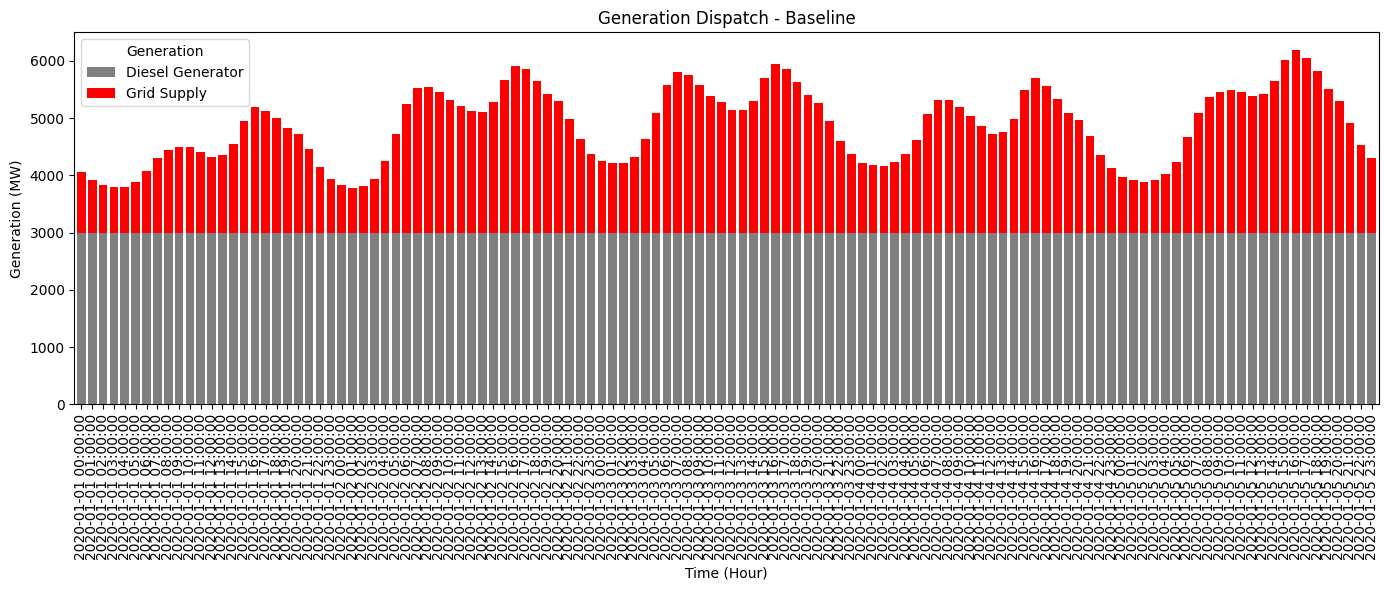

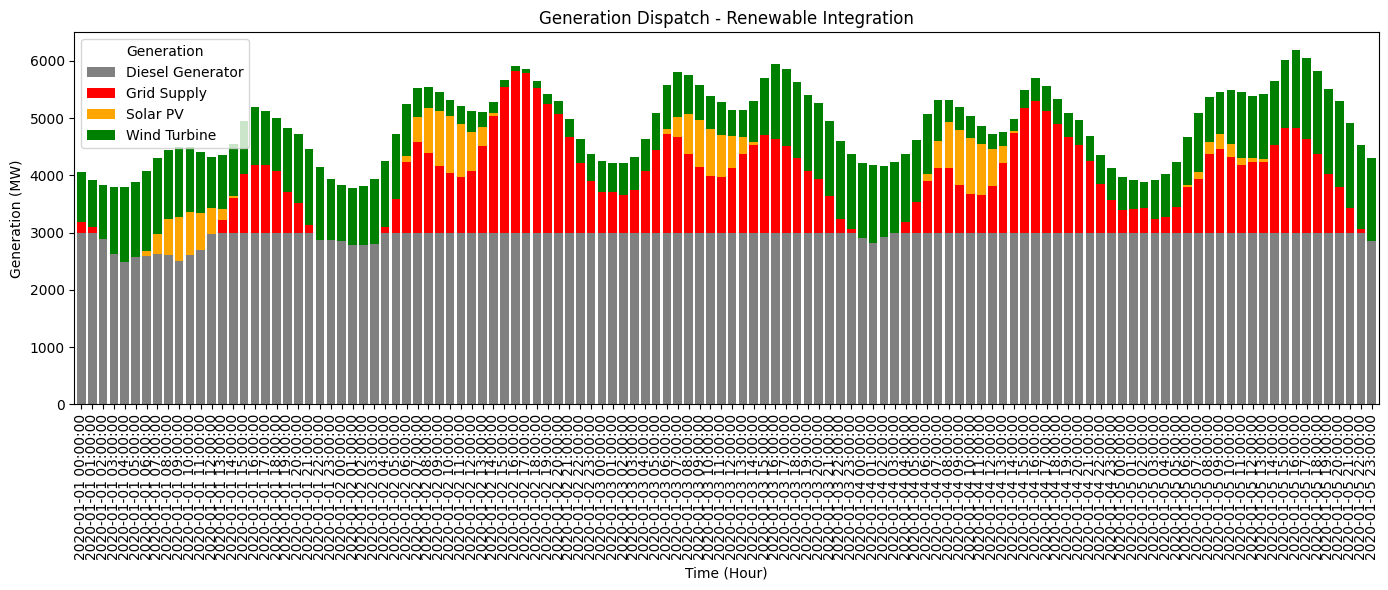

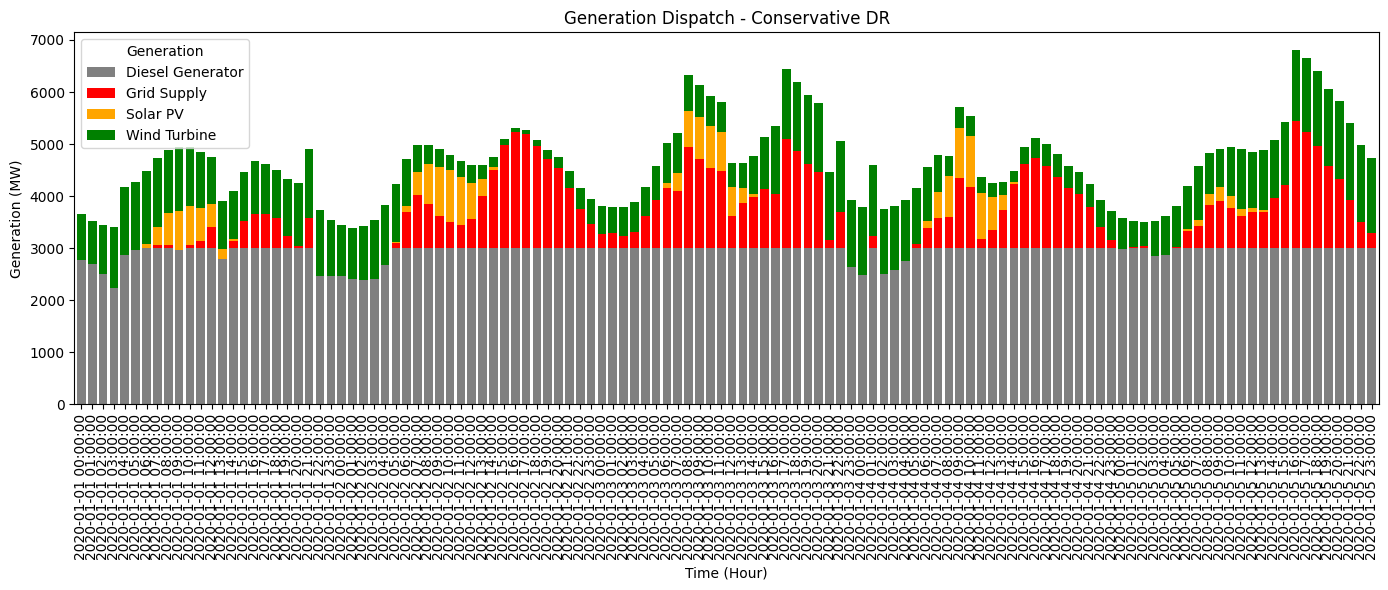

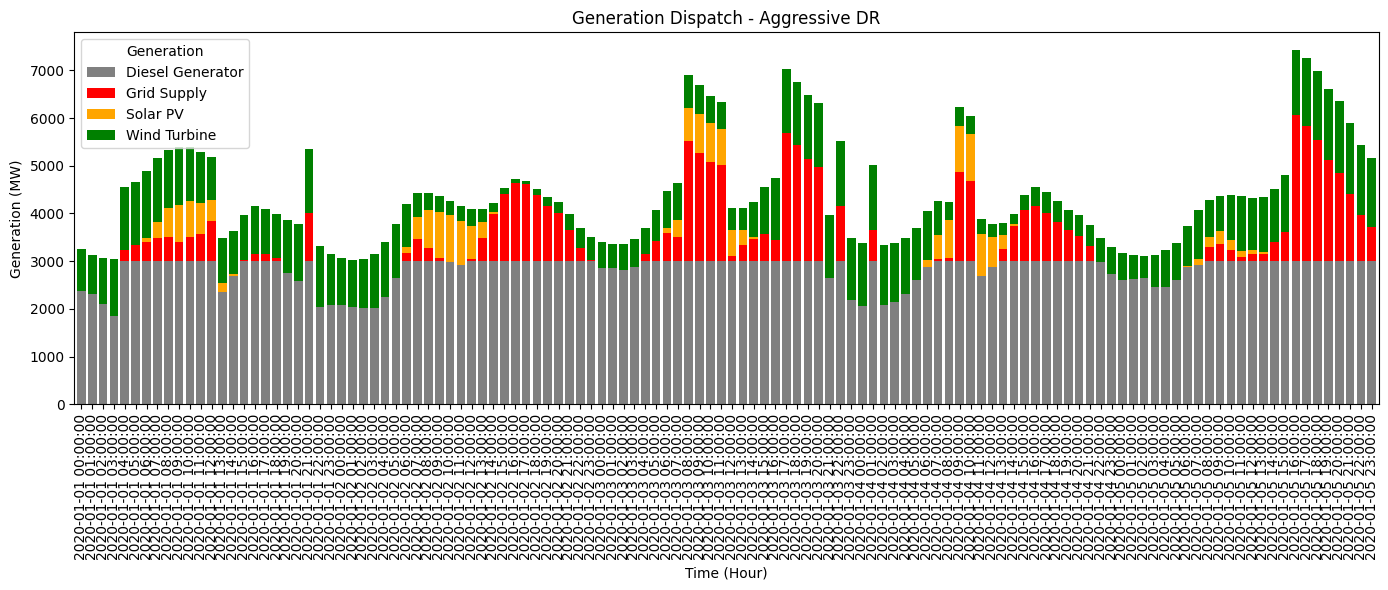

In [33]:
plot_dispatch(base_network, "Generation Dispatch - Baseline")
plot_dispatch(re_network, "Generation Dispatch - Renewable Integration")
plot_dispatch(conservative_network, "Generation Dispatch - Conservative DR")
plot_dispatch(aggressive_network, "Generation Dispatch - Aggressive DR")

In [35]:
# Renewable Utilization ratios
total_RE = solar_generation_profile.sum() + wind_generation_profile.sum()

consumption_baseline = initial_load.sum()
consumption_cons = load_cons.sum()
consumption_aggr = load_aggr.sum()

In [36]:
print(consumption_baseline, consumption_cons, consumption_aggr)

585293.0 556449.3 527605.6


In [37]:
utilization_baseline = total_RE / consumption_baseline

utilization_cons = total_RE / consumption_cons
utilization_aggr = total_RE / consumption_aggr

In [38]:
print(utilization_baseline, utilization_cons, utilization_aggr)

0.08574508835745516 0.09018970820881614 0.09512029440172735


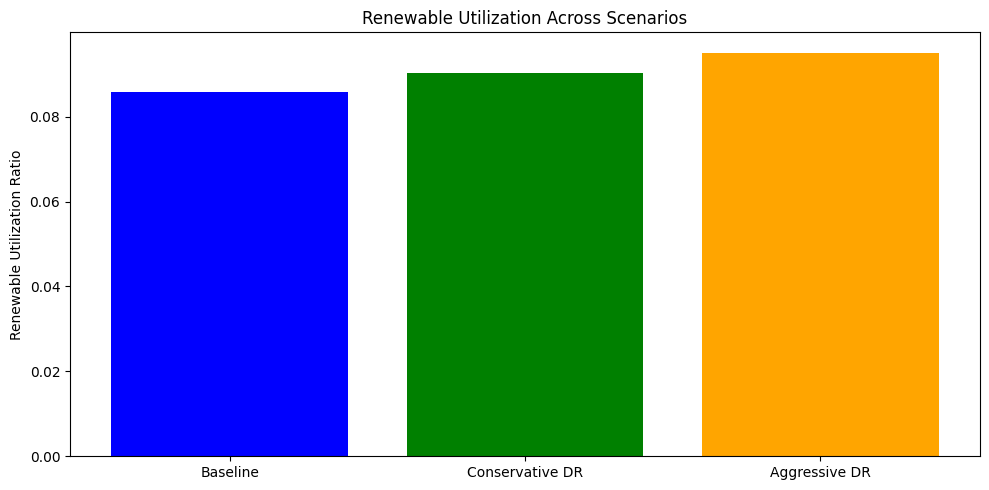

In [39]:
plt.figure(figsize=(10, 5))
plt.bar(
    ["Baseline", "Conservative DR", "Aggressive DR"],
    [utilization_baseline, utilization_cons, utilization_aggr],
    color=["blue", "green", "orange"],
)
plt.ylabel("Renewable Utilization Ratio")
plt.title("Renewable Utilization Across Scenarios")
plt.tight_layout()
plt.show()

# Economic KPI (total operational cost)


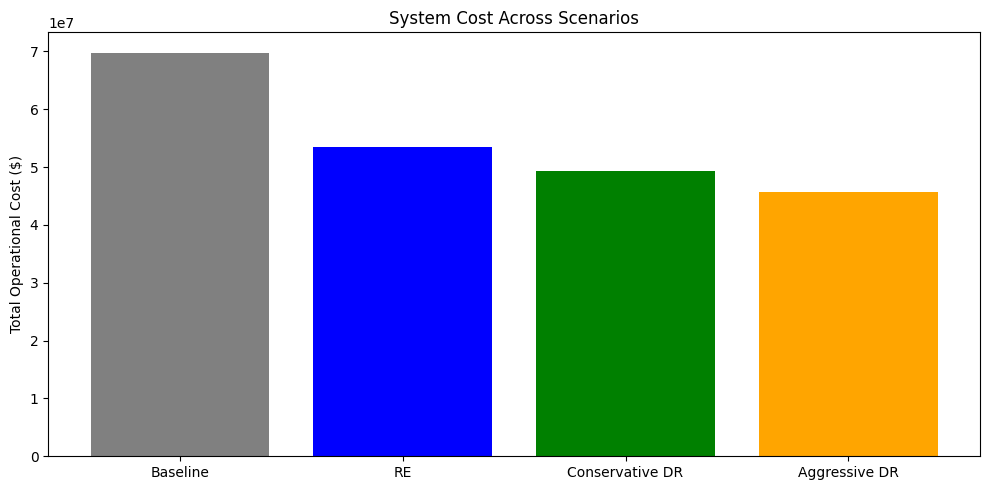

In [41]:
costs = [
    base_network.objective,
    re_network.objective,
    conservative_network.objective,
    aggressive_network.objective,
]
plt.figure(figsize=(10, 5))

plt.bar(
    ["Baseline", "RE", "Conservative DR", "Aggressive DR"],
    costs,
    color=["grey", "blue", "green", "orange"],
)
plt.ylabel("Total Operational Cost ($)")
plt.title("System Cost Across Scenarios")
plt.tight_layout()
plt.show()

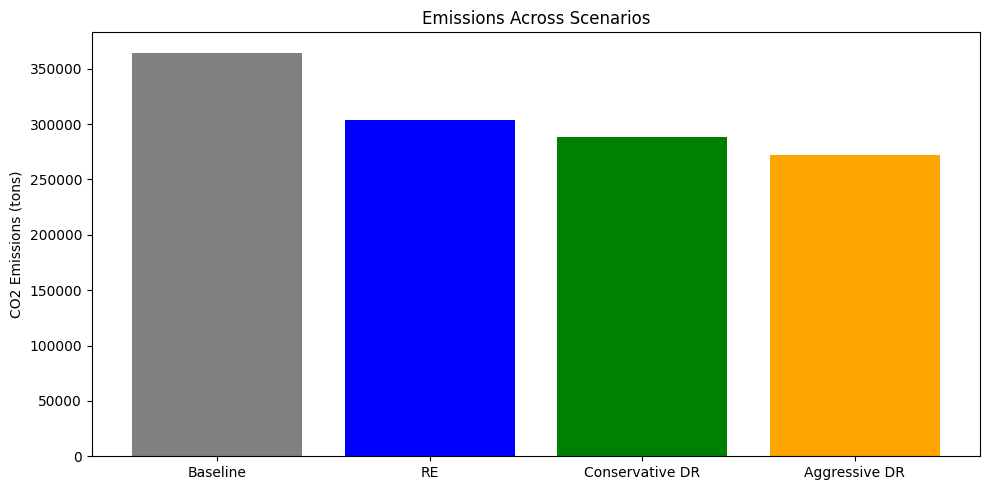


=== KPI Summary ===
Renewable Utilization (Baseline):    0.09
Renewable Utilization (Cons. DR):    0.09
Renewable Utilization (Aggr. DR):    0.10
System Cost (Baseline):              69793950.00 $
System Cost (Cons. DR):              49328462.04 $
System Cost (Aggr. DR):              45642773.17 $
Emissions (Baseline):                364646.50 tons
Emissions (Cons. DR):                288731.28 tons
Emissions (Aggr. DR):                271745.97 tons


In [42]:
def calculate_emissions(network):
    em = 0
    for gen in network.generators.index:
        if network.generators.carrier[gen] == "diesel":
            em += network.generators_t.p[gen].sum() * 0.7
        elif network.generators.carrier[gen] == "grid":
            em += network.generators_t.p[gen].sum() * 0.5
    return em


emissions = [
    calculate_emissions(base_network),
    calculate_emissions(re_network),
    calculate_emissions(conservative_network),
    calculate_emissions(aggressive_network),
]
plt.figure(figsize=(10, 5))
plt.bar(
    ["Baseline", "RE", "Conservative DR", "Aggressive DR"],
    emissions,
    color=["grey", "blue", "green", "orange"],
)
plt.ylabel("CO2 Emissions (tons)")
plt.title("Emissions Across Scenarios")
plt.tight_layout()
plt.show()

print("\n=== KPI Summary ===")
print(f"Renewable Utilization (Baseline):    {utilization_baseline:.2f}")
print(f"Renewable Utilization (Cons. DR):    {utilization_cons:.2f}")
print(f"Renewable Utilization (Aggr. DR):    {utilization_aggr:.2f}")
print(f"System Cost (Baseline):              {costs[0]:.2f} $")
print(f"System Cost (Cons. DR):              {costs[2]:.2f} $")
print(f"System Cost (Aggr. DR):              {costs[3]:.2f} $")
print(f"Emissions (Baseline):                {emissions[0]:.2f} tons")
print(f"Emissions (Cons. DR):                {emissions[2]:.2f} tons")
print(f"Emissions (Aggr. DR):                {emissions[3]:.2f} tons")